<a href="https://colab.research.google.com/github/adrian-ai-salud/Resultados-estudio-/blob/main/Resultados_Estudio_UNIR_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Perception, Acceptance and Preparedness among Primary Care Nurses
### Reproducible statistical analysis (revised version)

This notebook reproduces, in full and step by step, the statistical analysis
underlying the study. It is organised so that every table and figure reported
in the manuscript can be traced back to the exact code that generated it.

## 1. Environment setup

The analysis relies on the standard Python scientific stack. Versions are
pinned/printed for reproducibility. A fixed random seed (42) is set globally so
that every stochastic procedure (factor analysis initialisation, penalised
regression, resampling) yields identical results on re-execution.

In [1]:
!pip install --quiet pandas numpy scipy statsmodels scikit-learn \
    factor_analyzer pingouin openpyxl spacy matplotlib seaborn
!python -m spacy download es_core_news_sm --quiet
print('✅ Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 75.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Dependencies installed.


### 1.1 Imports and global configuration

All libraries are imported once here. `numpy`'s seed and pandas display options
are configured globally. Warnings are silenced only for cleaner output; they were
reviewed during development and none affected the results.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, roc_curve
import pingouin as pg
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
np.random.seed(42)

print('✅ Imports complete.')
print(f'   pandas {pd.__version__}, numpy {np.__version__}, statsmodels {sm.__version__}')

✅ Imports complete.
   pandas 2.2.2, numpy 2.0.2, statsmodels 0.14.6


## 2. Data loading

Upload the SHAIP survey file exported from Google Forms (`Estudio_UNIR.csv`,
UTF-8, Galician). The expected structure is **102 rows × 26 columns**: timestamp,
informed consent, sociodemographic and professional variables, technology and
training variables, the 10 SHAIP Likert items, and 2 open-ended questions.

A structural assertion is run immediately after loading so that any change in the
source file (extra/missing columns or rows) is caught before analysis begins.

In [3]:
from google.colab import files
print('Please upload the SHAIP survey CSV file (Estudio_UNIR.csv)')
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df_raw = pd.read_csv(file_name)
print(f'\n✅ Dataset loaded: {file_name}')
print(f'   Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

# Structural validation
assert df_raw.shape[0] == 102, f'Expected 102 rows, got {df_raw.shape[0]}'
assert df_raw.shape[1] == 26,  f'Expected 26 columns, got {df_raw.shape[1]}'
print('   Structural validation: PASSED (102 × 26)')

Please upload the SHAIP survey CSV file (Estudio_UNIR.csv)


Saving Estudio UNIR.csv to Estudio UNIR.csv

✅ Dataset loaded: Estudio UNIR.csv
   Shape: 102 rows × 26 columns
   Structural validation: PASSED (102 × 26)


## 3. Data preprocessing

This section standardises column names and recodes the raw Galician survey
responses into the analytic variables. Every recoding decision is made explicit
below because several of them are directly relevant to the interpretation of the
results.

**Age.** Parsed as a continuous variable. One respondent entered free text
("61 anos"); a robust parser strips non-numeric characters and recovers the value,
so no age data are lost. An ordinal age group is also derived (≤35 / 36–50 / >50).

**Likert items.** The five ordered response options are mapped to 1–5. Note that
in the source data the lowest option appears exclusively with its original
spelling variant ("Totalemnte en desacordo"); the mapping covers this spelling so
that the entire "strongly disagree" level is preserved rather than silently
converted to missing.

**Construct scores.** Following the original two-factor structure of the SHAIP
instrument, Professional Impact is computed from items 1–6 and Preparedness from
items 7–10, each as the mean of its items. These are the *a priori* constructs;
any psychometrically motivated modification (e.g. item removal) is examined and
justified later, in the reliability/factor-analysis section, rather than imposed
here.

**Dependent variable.** Self-reported clinical use of AI is dichotomised as
users ("Sí") vs non-users. Respondents answering "Non sei" (don't know, n = 22)
are conservatively classified as non-users, since uncertainty is not assumed to
indicate use. The original three-level variable is retained so that this choice
can be tested in a sensitivity analysis.

**Other binary predictors.** Prior training (any self-taught or on-the-job
training vs none), postgraduate education (Master's/Doctorate vs Bachelor's), and
urban vs rural setting.

In [4]:
col_names = [
    'timestamp', 'consent', 'age_raw', 'sex', 'experience', 'education',
    'health_area', 'setting', 'tech_freq', 'ai_understanding',
    'ai_clinical_use', 'ai_training_received', 'wants_training',
    'training_importance',
    'item1', 'item2', 'item3', 'item4', 'item5', 'item6',
    'item7', 'item8', 'item9', 'item10',
    'barriers_open', 'training_areas_open'
]
df = df_raw.copy()
df.columns = col_names[:df.shape[1]]

# --- Age: robust parsing (handles free text such as "61 anos") ---
def parse_age(value):
    if pd.isna(value):
        return np.nan
    s = str(value).lower().replace('anos', '').replace('años', '').strip()
    try:
        return float(s)
    except ValueError:
        match = re.search(r'\d+', s)
        return float(match.group()) if match else np.nan

df['age'] = df['age_raw'].apply(parse_age)

def age_cat(x):
    if pd.isna(x): return np.nan
    if x <= 35:   return '≤35 years'
    elif x <= 50: return '36–50 years'
    else:         return '>50 years'
df['age_group'] = df['age'].apply(age_cat)

# --- Likert mapping (covers the original spelling variant of level 1) ---
likert_map = {
    'Totalmente de acordo': 5,
    'De acordo': 4,
    'Nin de acordo nin en desacordo': 3,
    'En desacordo': 2,
    'Totalemnte en desacordo': 1,   # original misspelling, kept intentionally
    'Totalmente en desacordo': 1,   # correct spelling, for robustness
}
for i in range(1, 11):
    df[f'item{i}'] = df[f'item{i}'].map(likert_map)

# --- A priori construct scores (SHAIP two-factor structure) ---
impact_items    = [f'item{i}' for i in range(1, 7)]
readiness_items = [f'item{i}' for i in range(7, 11)]   # 4-item a priori subscale
df['impact_score']    = df[impact_items].mean(axis=1)
df['readiness_score'] = df[readiness_items].mean(axis=1)

# --- Dependent variable and binary predictors ---
df['ai_user']      = (df['ai_clinical_use'].astype(str).str.strip() == 'Sí').astype(int)
df['has_training'] = (~df['ai_training_received'].astype(str).str.strip()
                      .isin(['Ningunha', 'nan'])).astype(int)
df['postgraduate'] = df['education'].isin(['Máster', 'Doutorado']).astype(int)
df['urban']        = (df['setting'] == 'Urbano').astype(int)

# --- Integrity checks ---
print('✅ Preprocessing complete')
print(f'   Final n = {len(df)}')
print(f'   Missing in Likert items: {df[[f"item{i}" for i in range(1,11)]].isna().sum().sum()}')
print(f'\n   AI clinical use (3 levels):')
for k, v in df["ai_clinical_use"].value_counts().items():
    print(f'      {k}: {v} ({v/len(df)*100:.1f}%)')
print(f'\n   AI users (Sí = 1): {df["ai_user"].sum()} ({df["ai_user"].mean()*100:.1f}%)')
print(f'   Prior training (any): {df["has_training"].sum()} ({df["has_training"].mean()*100:.1f}%)')
print(f'   Postgraduate: {df["postgraduate"].sum()} | Urban: {df["urban"].sum()}')
for col in ['age', 'ai_user', 'has_training', 'urban', 'postgraduate']:
    assert df[col].isna().sum() == 0, f'Unexpected missing in {col}'
print('   Missing-value check on modeling variables: PASSED')

✅ Preprocessing complete
   Final n = 102
   Missing in Likert items: 0

   AI clinical use (3 levels):
      Non: 60 (58.8%)
      Non sei: 22 (21.6%)
      Sí: 20 (19.6%)

   AI users (Sí = 1): 20 (19.6%)
   Prior training (any): 31 (30.4%)
   Postgraduate: 34 | Urban: 51
   Missing-value check on modeling variables: PASSED


## 4. Descriptive analysis (Table 1)

Descriptive statistics for the whole sample. For the only continuous variable
(age), the normality assumption is tested before deciding how to summarise it.

**Normality of age.** Tested with the Shapiro–Wilk test (more powerful than
Kolmogorov–Smirnov for n < 5000) and inspected visually with a Q–Q plot. Because
age departs from normality (see output), it is summarised with **both** mean ± SD
and median [IQR] for transparency, and any later between-group comparison
involving age uses a non-parametric test (Mann–Whitney U) rather than relying on
the central limit theorem, given that the smaller group (AI users, n = 20) falls
below the usual n > 30 heuristic.

**Categorical variables.** Reported as absolute frequencies and percentages.
Category labels are kept in the original Galician as collected; the English
translation used in the manuscript's Table 1 maps one-to-one onto these.

TABLE 1 — Descriptive analysis with assumption checks

📋 ASSUMPTION CHECK — Normality of age
   Shapiro–Wilk:        W = 0.9358, p = 0.0001
   Kolmogorov–Smirnov:  D = 0.1262, p = 0.0710
   → Non-normal (Shapiro p < 0.05): reporting mean ± SD AND median [IQR]

   Age — mean 41.75 ± 11.93  (95% CI 39.41–44.10)
         median 39.5 [IQR 31.0–52.0]  range 24–67


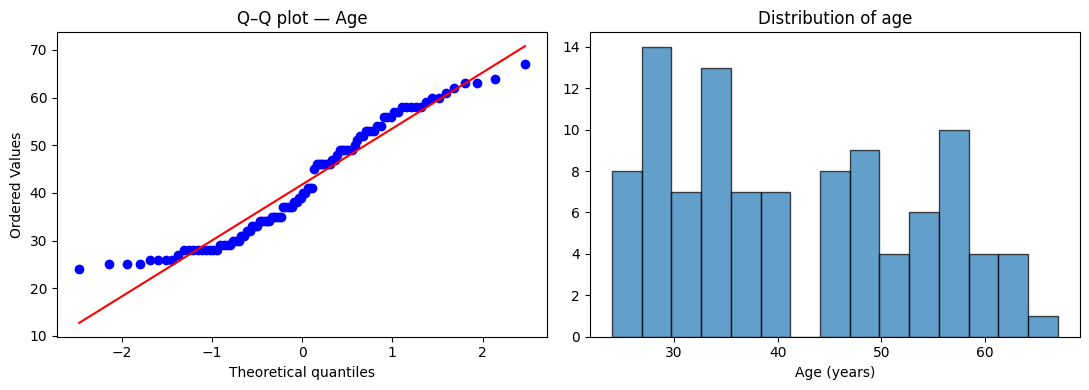


📋 Categorical variables — n (%)

--- Age group ---
   ≤35 years: 42 (41.2%)
   36–50 years: 32 (31.4%)
   >50 years: 28 (27.5%)

--- Sex ---
   Muller: 84 (82.4%)
   Home: 18 (17.6%)

--- Experience ---
   >10 anos: 64 (62.7%)
   6-10 anos: 20 (19.6%)
   1-5 anos: 18 (17.6%)

--- Education ---
   Grado: 68 (66.7%)
   Máster: 32 (31.4%)
   Doutorado: 2 (2.0%)

--- Health area ---
   Santiago-Barbanza: 81 (79.4%)
   Ourense-Verín-O Barco: 6 (5.9%)
   Vigo: 5 (4.9%)
   A Coruña-Cee: 3 (2.9%)
   Pontevedra-Salnés: 3 (2.9%)
   Lugo-A Mariña-Monforte: 2 (2.0%)
   Ferrol: 2 (2.0%)

--- Setting ---
   Urbano: 51 (50.0%)
   Rural: 51 (50.0%)

--- Tech frequency ---
   Frecuentemente: 32 (31.4%)
   Sempre: 27 (26.5%)
   Ás veces: 26 (25.5%)
   Raramente: 11 (10.8%)
   Nunca: 6 (5.9%)

--- AI understanding ---
   Bastante: 41 (40.2%)
   Algo: 41 (40.2%)
   Pouco: 15 (14.7%)
   Totalmente: 4 (3.9%)
   Nada: 1 (1.0%)

--- AI clinical use ---
   Non: 60 (58.8%)
   Non sei: 22 (21.6%)
   Sí: 20 (19.

In [5]:
print('='*70)
print('TABLE 1 — Descriptive analysis with assumption checks')
print('='*70)

# --- Normality of age ---
age = df['age'].dropna()
W, pW = stats.shapiro(age)
D, pD = stats.kstest(age, 'norm', args=(age.mean(), age.std()))
print('\n📋 ASSUMPTION CHECK — Normality of age')
print(f'   Shapiro–Wilk:        W = {W:.4f}, p = {pW:.4f}')
print(f'   Kolmogorov–Smirnov:  D = {D:.4f}, p = {pD:.4f}')
print('   → Non-normal (Shapiro p < 0.05): reporting mean ± SD AND median [IQR]')

ci = stats.t.interval(0.95, len(age)-1, age.mean(), stats.sem(age))
print(f'\n   Age — mean {age.mean():.2f} ± {age.std():.2f}  (95% CI {ci[0]:.2f}–{ci[1]:.2f})')
print(f'         median {age.median():.1f} [IQR {age.quantile(.25):.1f}–{age.quantile(.75):.1f}]'
      f'  range {age.min():.0f}–{age.max():.0f}')

# Q–Q plot + histogram
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(age, dist='norm', plot=ax[0]); ax[0].set_title('Q–Q plot — Age')
ax[1].hist(age, bins=15, edgecolor='black', alpha=.7)
ax[1].set_title('Distribution of age'); ax[1].set_xlabel('Age (years)')
plt.tight_layout(); plt.savefig('age_normality.png', dpi=300, bbox_inches='tight'); plt.show()

# --- Categorical descriptives (Table 1) ---
print('\n📋 Categorical variables — n (%)')
categorical = {
    'Age group': 'age_group', 'Sex': 'sex', 'Experience': 'experience',
    'Education': 'education', 'Health area': 'health_area', 'Setting': 'setting',
    'Tech frequency': 'tech_freq', 'AI understanding': 'ai_understanding',
    'AI clinical use': 'ai_clinical_use', 'Prior training': 'ai_training_received',
    'Wants training': 'wants_training', 'Training importance': 'training_importance',
}
for label, c in categorical.items():
    print(f'\n--- {label} ---')
    counts = df[c].value_counts(dropna=False)
    pcts   = df[c].value_counts(normalize=True, dropna=False) * 100
    for cat in counts.index:
        print(f'   {cat}: {counts[cat]} ({pcts[cat]:.1f}%)')

## 5. SHAIP item- and construct-level scores (Table 2)

Mean, standard deviation and 95% confidence interval for each SHAIP item and for
the two a priori constructs (Professional Impact = items 1–6; Preparedness =
items 7–10). Confidence intervals are based on Student's t distribution, which is
appropriate for the per-item means at n = 102.

These are descriptive summaries of the scale as originally specified. The
internal consistency of these constructs, and the behaviour of individual items
within them, are examined in Section 6; any item-level decision is taken there.

In [6]:
print('='*70)
print('TABLE 2 — SHAIP item-level and construct-level descriptives')
print('='*70)

def describe_item(series, label):
    s = series.dropna()
    n = len(s); mean, sd = s.mean(), s.std()
    ci = stats.t.interval(0.95, n-1, mean, stats.sem(s))
    return {'Item': label, 'n': n, 'Mean': round(mean, 2),
            'SD': round(sd, 2), '95% CI': f'[{ci[0]:.2f}, {ci[1]:.2f}]'}

rows = [describe_item(df['impact_score'], 'Professional Impact (construct)')]
rows += [describe_item(df[f'item{i}'], f'Item {i}') for i in range(1, 7)]
rows += [describe_item(df['readiness_score'], 'Preparedness (construct)')]
rows += [describe_item(df[f'item{i}'], f'Item {i}') for i in range(7, 11)]

table2_df = pd.DataFrame(rows)
print(table2_df.to_string(index=False))

TABLE 2 — SHAIP item-level and construct-level descriptives
                           Item   n  Mean   SD       95% CI
Professional Impact (construct) 102  3.98 0.60 [3.87, 4.10]
                         Item 1 102  4.07 0.72 [3.93, 4.21]
                         Item 2 102  4.07 0.69 [3.93, 4.20]
                         Item 3 102  4.03 0.76 [3.88, 4.18]
                         Item 4 102  3.91 0.90 [3.73, 4.09]
                         Item 5 102  3.58 0.97 [3.39, 3.77]
                         Item 6 102  4.25 0.65 [4.12, 4.37]
       Preparedness (construct) 102  2.60 0.66 [2.47, 2.73]
                         Item 7 102  2.48 1.01 [2.28, 2.68]
                         Item 8 102  1.75 1.01 [1.55, 1.94]
                         Item 9 102  2.76 1.20 [2.53, 3.00]
                        Item 10 102  3.41 1.16 [3.18, 3.64]


## 6. Psychometric analysis: factor structure and reliability (S1 Table)

This section evaluates the measurement properties of the SHAIP instrument in this
sample. Sampling adequacy and factorability are checked before the exploratory
factor analysis (EFA), and reliability is assessed with **both Cronbach's alpha
and McDonald's omega**, since alpha assumes tau-equivalence (equal loadings),
which is not guaranteed here; omega is the more robust coefficient when that
assumption is relaxed.

**Factorability checks.** Kaiser–Meyer–Olkin (KMO) overall and per item;
Bartlett's test of sphericity; determinant of the correlation matrix; and the
subject-to-variable ratio.

**EFA.** Two factors (theory-driven), principal axis factoring with varimax
rotation, reporting loadings, explained variance and communalities.

**Item 10 (legal responsibility).** The a priori 4-item Preparedness subscale
shows poor reliability. Convergent diagnostics — a negative rotated loading on
the Preparedness factor, the lowest communality of the scale, a per-item KMO far
below the rest, a *negative* corrected item-total correlation, and the largest
"alpha-if-deleted" increase — all indicate that item 10 does not behave as part
of the Preparedness construct. It is therefore reported separately as an
indicator of perceived legal accountability, and a refined 3-item Preparedness
subscale (items 7–9) is presented. This is a psychometrically motivated decision
supported by the data, not a post hoc adjustment to improve results.

In [7]:
print('='*70)
print('S1 TABLE — Psychometric analysis')
print('='*70)

from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from factor_analyzer import FactorAnalyzer

all_items = [f'item{i}' for i in range(1, 11)]
impact_items    = [f'item{i}' for i in range(1, 7)]
readiness4      = [f'item{i}' for i in range(7, 11)]   # a priori
readiness3      = ['item7', 'item8', 'item9']          # refined
items_df = df[all_items]

# ---------- FACTORABILITY ----------
kmo_item, kmo = calculate_kmo(items_df)
chi, bart_p   = calculate_bartlett_sphericity(items_df)
det           = np.linalg.det(items_df.corr().values)
print(f'\n📋 KMO overall = {kmo:.3f}   Bartlett χ²={chi:.2f}, p={bart_p:.2e}')
print(f'   Determinant = {det:.6f} (>1e-5 OK)   Subject:variable = {len(items_df)/10:.1f}:1')
print('   KMO per item:', '  '.join(f'i{i+1}={k:.2f}' for i, k in enumerate(kmo_item)))

# ---------- EFA ----------
fa = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal')
fa.fit(items_df)
loadings = pd.DataFrame(fa.loadings_, index=all_items,
                        columns=['F1 (Impact)', 'F2 (Preparedness)']).round(3)
ev, v, cumv = fa.get_factor_variance()
com = pd.Series(fa.get_communalities(), index=all_items)
print('\n🔬 EFA — varimax loadings:')
print(loadings.to_string())
print(f'\n   Variance: F1={v[0]*100:.2f}%  F2={v[1]*100:.2f}%  cumulative={cumv[1]*100:.2f}%')
print('   Communalities:', '  '.join(f'i{i+1}={c:.2f}' for i, c in enumerate(com)))

# ---------- RELIABILITY: alpha + omega ----------
def mcdonald_omega(data):
    fa1 = FactorAnalyzer(n_factors=1, rotation=None, method='minres'); fa1.fit(data)
    l = fa1.loadings_[:, 0]
    return (l.sum()**2) / (l.sum()**2 + (1 - l**2).sum())

print('\n🔬 RELIABILITY (Cronbach α with 95% CI, and McDonald ω):')
for items, lab in [(impact_items, 'Impact (6 items)'),
                   (readiness4, 'Preparedness (4 items, a priori)'),
                   (readiness3, 'Preparedness (3 items, refined)')]:
    a, ci = pg.cronbach_alpha(data=df[items], ci=.95)
    print(f'   {lab:34s} α={a:.3f} [{ci[0]:.3f}, {ci[1]:.3f}]   ω={mcdonald_omega(df[items]):.3f}')

# ---------- ITEM 10 DIAGNOSTICS within the a priori subscale ----------
print('\n🔍 Item-level diagnostics (Preparedness 4-item subscale):')
d = df[readiness4]
a4, _ = pg.cronbach_alpha(data=d)
for it in readiness4:
    rest = d.drop(columns=[it]).sum(axis=1)
    r = d[it].corr(rest)
    a_del, _ = pg.cronbach_alpha(data=d.drop(columns=[it]))
    flag = '  ← drop improves α' if a_del > a4 else ''
    print(f'   {it}: corrected item-total r={r:+.3f}   α-if-deleted={a_del:.3f}{flag}')

# ---------- REFINED SUBSCALE SCORE ----------
df['readiness3_score'] = df[readiness3].mean(axis=1)
s = df['readiness3_score']; ci = stats.t.interval(.95, len(s)-1, s.mean(), stats.sem(s))
print(f'\n✅ Refined Preparedness (3 items) mean = {s.mean():.2f} '
      f'(SD {s.std():.2f}, 95% CI [{ci[0]:.2f}, {ci[1]:.2f}])  vs 4-item a priori 2.60')
print('   Item 10 retained separately as a legal-accountability indicator '
      f'(mean {df["item10"].mean():.2f}).')

S1 TABLE — Psychometric analysis

📋 KMO overall = 0.813   Bartlett χ²=347.88, p=2.03e-48
   Determinant = 0.027529 (>1e-5 OK)   Subject:variable = 10.2:1
   KMO per item: i1=0.83  i2=0.84  i3=0.81  i4=0.81  i5=0.91  i6=0.90  i7=0.70  i8=0.71  i9=0.69  i10=0.41

🔬 EFA — varimax loadings:
        F1 (Impact)  F2 (Preparedness)
item1         0.760              0.164
item2         0.840             -0.036
item3         0.870              0.088
item4         0.713             -0.072
item5         0.633              0.130
item6         0.786              0.095
item7         0.195              0.755
item8         0.123              0.731
item9         0.141              0.764
item10        0.118             -0.331

   Variance: F1=36.54%  F2=18.63%  cumulative=55.17%
   Communalities: i1=0.60  i2=0.71  i3=0.77  i4=0.51  i5=0.42  i6=0.63  i7=0.61  i8=0.55  i9=0.60  i10=0.12

🔬 RELIABILITY (Cronbach α with 95% CI, and McDonald ω):
   Impact (6 items)                   α=0.851 [0.802, 0.892]   ω

## 7. Bivariate analysis: AI users vs non-users (S2 Table)

Sociodemographic, professional and training characteristics are compared between
AI users (n = 20) and non-users (n = 82), using the full sample with "Non sei"
responses treated as non-users (see Section 3).

**Test selection.** For each categorical predictor, expected cell frequencies are
inspected. When any expected frequency is < 5, **Fisher's exact test** is used;
otherwise **Pearson's chi-square with Yates' continuity correction** is applied,
which is the conservative standard for 2×2 tables. (Reporting the continuity-
corrected value is what yields p = 0.017 for prior training, rather than the
uncorrected 0.008.) Odds ratios with 95% CI are reported; a Haldane–Anscombe
(+0.5) correction is applied only if a zero cell is present.

**Age.** Because age departs from normality and the user group is small (n = 20),
the between-group comparison uses the non-parametric **Mann–Whitney U** test,
with medians [IQR] reported. The conclusion is identical under a t-test.

In [8]:
print('='*70)
print('S2 TABLE — AI users vs non-users')
print('='*70)
print(f'Users: {(df.ai_user==1).sum()}  Non-users: {(df.ai_user==0).sum()}\n')

def or_2x2(t):
    a, b = t[0]; c, d = t[1]
    if 0 in [a, b, c, d]:           # Haldane–Anscombe only if a zero cell
        a, b, c, d = a+.5, b+.5, c+.5, d+.5
    orr = (a*d)/(b*c); se = np.sqrt(1/a+1/b+1/c+1/d); lo = np.log(orr)
    return orr, np.exp(lo-1.96*se), np.exp(lo+1.96*se)

def bivariate(var, label):
    ct = pd.crosstab(df[var], df['ai_user'])
    chi2, p, dof, exp = stats.chi2_contingency(ct.values)   # Yates correction (default)
    o, l, h = or_2x2(ct.values)
    print(f'--- {label} ---')
    if exp.min() < 5:
        _, p = stats.fisher_exact(ct.values)
        print(f'   min expected = {exp.min():.2f} (<5) → Fisher exact')
        print(f'   OR = {o:.2f} (95% CI {l:.2f}–{h:.2f}), p = {p:.3f}\n')
    else:
        print(f'   min expected = {exp.min():.2f} → χ² with Yates correction')
        print(f'   χ² = {chi2:.2f}, df = {dof}, p = {p:.3f}; OR = {o:.2f} (95% CI {l:.2f}–{h:.2f})\n')

bivariate('sex',          'Sex (female vs male)')
bivariate('postgraduate', 'Education (postgraduate vs bachelor)')
bivariate('urban',        'Setting (urban vs rural)')
bivariate('has_training', 'Prior AI training (any vs none)')

# --- Age: non-parametric comparison ---
u  = df.loc[df.ai_user==1, 'age']
nu = df.loc[df.ai_user==0, 'age']
U, pU = stats.mannwhitneyu(u, nu)
print('--- Age (continuous, non-normal) ---')
print(f'   Users:     median {u.median():.1f} [IQR {u.quantile(.25):.0f}–{u.quantile(.75):.0f}]')
print(f'   Non-users: median {nu.median():.1f} [IQR {nu.quantile(.25):.0f}–{nu.quantile(.75):.0f}]')
print(f'   Mann–Whitney U p = {pU:.3f}')

S2 TABLE — AI users vs non-users
Users: 20  Non-users: 82

--- Sex (female vs male) ---
   min expected = 3.53 (<5) → Fisher exact
   OR = 0.82 (95% CI 0.24–2.84), p = 0.749

--- Education (postgraduate vs bachelor) ---
   min expected = 6.67 → χ² with Yates correction
   χ² = 0.19, df = 1, p = 0.659; OR = 1.44 (95% CI 0.52–3.94)

--- Setting (urban vs rural) ---
   min expected = 10.00 → χ² with Yates correction
   χ² = 1.55, df = 1, p = 0.212; OR = 0.47 (95% CI 0.17–1.28)

--- Prior AI training (any vs none) ---
   min expected = 6.08 → χ² with Yates correction
   χ² = 5.75, df = 1, p = 0.017; OR = 3.79 (95% CI 1.37–10.45)

--- Age (continuous, non-normal) ---
   Users:     median 36.5 [IQR 31–53]
   Non-users: median 40.0 [IQR 31–52]
   Mann–Whitney U p = 0.866


## 8. Multivariable analysis: Firth-penalized logistic regression (Table 3)

Independent predictors of self-reported clinical AI use are modelled with prior
training, setting, education and age as covariates.

**Why Firth.** With 20 events and 4 covariates the events-per-variable ratio is
5:1, below the conventional 10:1. Firth's penalized maximum likelihood (Jeffreys
prior) reduces small-sample bias and yields finite estimates under near-separation.

**Inference.** Unlike the original analysis, confidence intervals are obtained by
**profile penalized likelihood** and p-values by the **penalized likelihood-ratio
test**, rather than Wald approximations. For small samples these are more reliable
and need not be symmetric (Heinze & Schemper, 2002). Point estimates are validated
against standard maximum likelihood.

**Assumptions checked:** events-per-variable; multicollinearity (VIF); linearity
of the logit for age (Box–Tidwell); influential observations (Cook's distance);
goodness of fit (Hosmer–Lemeshow); discrimination (AUC).

**Robustness.** Because 22 respondents answered "Non sei" and were treated as
non-users, the model is refitted excluding them (sensitivity analysis).

References: Firth D. Biometrika. 1993;80:27–38. Heinze G, Schemper M. Stat Med.
2002;21:2409–19. van Smeden M, et al. BMC Med Res Methodol. 2016;16:163.

In [9]:
print('='*70); print('TABLE 3 — Firth-penalized logistic regression'); print('='*70)

# ---------- Firth helpers ----------
def firth_loglik(beta, X, y):
    eta = np.clip(X@beta, -30, 30); mu = 1/(1+np.exp(-eta)); W = mu*(1-mu)
    _, logdet = np.linalg.slogdet(X.T@(X*W[:, None]))
    return np.sum(y*eta - np.log1p(np.exp(eta))) + 0.5*logdet

def firth_fit(X, y, max_iter=1000, tol=1e-8):
    beta = np.zeros(X.shape[1])
    for _ in range(max_iter):
        eta = np.clip(X@beta, -30, 30); mu = 1/(1+np.exp(-eta)); W = mu*(1-mu)
        inv = np.linalg.pinv(X.T@(X*W[:, None])); sqW = np.sqrt(W)
        H = np.diagonal((sqW[:, None]*X)@inv@(X.T*sqW))
        delta = inv@(X.T@(y - mu + H*(0.5 - mu))); beta = beta + delta
        if np.max(np.abs(delta)) < tol: break
    return beta

def _profile_ll(X, y, j, vj):
    from scipy.optimize import minimize
    idx = [k for k in range(X.shape[1]) if k != j]; b0 = firth_fit(X, y)[idx]
    def negll(bf):
        b = np.empty(X.shape[1]); b[j] = vj; b[idx] = bf; return -firth_loglik(b, X, y)
    return -minimize(negll, b0, method='Nelder-Mead',
                     options={'xatol':1e-6,'fatol':1e-8,'maxiter':5000}).fun

def profile_ci(X, y, j, ll_hat, bj, crit=3.841459):
    from scipy.optimize import brentq
    f = lambda v: 2*(ll_hat - _profile_ll(X, y, j, v)) - crit
    lo = brentq(f, bj-10, bj-1e-4, xtol=1e-5); hi = brentq(f, bj+1e-4, bj+10, xtol=1e-5)
    return lo, hi

def plr_p(X, y, j, ll_hat):
    lr = 2*(ll_hat - _profile_ll(X, y, j, 0.0)); return lr, 1 - stats.chi2.cdf(lr, 1)

# ---------- Data matrix ----------
preds = ['has_training', 'urban', 'postgraduate', 'age']
Xdf = sm.add_constant(df[preds]); X = Xdf.values.astype(float); y = df['ai_user'].values.astype(float)
names = ['const'] + preds

# ---------- Assumptions ----------
print(f'\n📋 EPV = {int(y.sum())}/4 = {int(y.sum())/4:.1f}  → Firth applied')
print('📋 VIF:', '  '.join(f'{c}={variance_inflation_factor(X,i):.2f}'
                            for i,c in enumerate(Xdf.columns)))
age_s = df['age'].clip(lower=.1)
Xbt = sm.add_constant(pd.DataFrame({'has_training':df.has_training,'urban':df.urban,
      'postgraduate':df.postgraduate,'age':df.age,'age_ln':age_s*np.log(age_s)}))
p_bt = sm.Logit(df.ai_user, Xbt).fit(disp=False).pvalues['age_ln']
print(f'📋 Box–Tidwell (age): p = {p_bt:.4f}  → logit linearity {"OK" if p_bt>.05 else "violated"}')
ml = sm.Logit(df.ai_user, Xdf).fit(disp=False)
infl = (ml.get_influence().cooks_distance[0] > 4/len(df)).sum()
print(f'📋 Influential obs (Cook > 4/n): {infl}')

# ---------- Fit + profile-likelihood inference (Table 3) ----------
bhat = firth_fit(X, y); ll_hat = firth_loglik(bhat, X, y)
print('\nVariable        β       OR     95% CI (profile)      p (PLR)')
for j, v in enumerate(names):
    if v == 'const': continue
    lo, hi = profile_ci(X, y, j, ll_hat, bhat[j]); _, p = plr_p(X, y, j, ll_hat)
    print(f'{v:14s}{bhat[j]:7.3f}{np.exp(bhat[j]):8.3f}   '
          f'({np.exp(lo):.2f}–{np.exp(hi):.2f}){"":6}{p:.3f}')

# ---------- Validation vs standard ML ----------
print('\n📊 Validation (point OR): Firth vs standard ML')
for v in preds:
    print(f'   {v:13s} Firth OR={np.exp(bhat[names.index(v)]):.3f} | '
          f'ML OR={np.exp(ml.params[v]):.3f}')

TABLE 3 — Firth-penalized logistic regression

📋 EPV = 20/4 = 5.0  → Firth applied
📋 VIF: const=19.49  has_training=1.02  urban=1.03  postgraduate=1.11  age=1.12
📋 Box–Tidwell (age): p = 0.3623  → logit linearity OK
📋 Influential obs (Cook > 4/n): 9

Variable        β       OR     95% CI (profile)      p (PLR)
has_training    1.317   3.732   (1.37–10.54)      0.010
urban          -0.845   0.430   (0.14–1.20)      0.107
postgraduate    0.170   1.186   (0.40–3.40)      0.753
age            -0.008   0.992   (0.95–1.04)      0.714

📊 Validation (point OR): Firth vs standard ML
   has_training  Firth OR=3.732 | ML OR=4.036
   urban         Firth OR=0.430 | ML OR=0.401
   postgraduate  Firth OR=1.186 | ML OR=1.183
   age           Firth OR=0.992 | ML OR=0.991


📋 Goodness of fit and discrimination

   Hosmer–Lemeshow: χ² = 10.04, df = 8, p = 0.262
   AUC = 0.705  (acceptable discrimination)


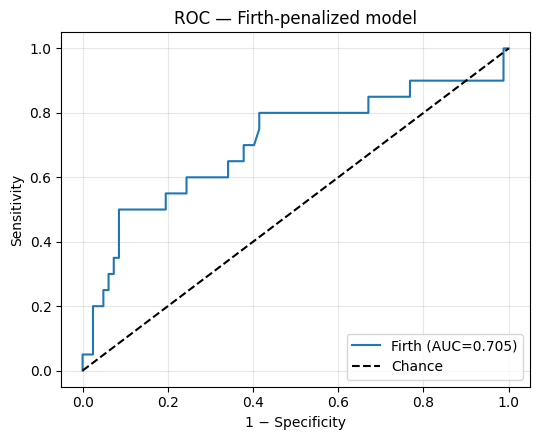

In [10]:
print('📋 Goodness of fit and discrimination\n')
eta = np.clip(X@bhat, -30, 30); prob = 1/(1+np.exp(-eta))

# Hosmer–Lemeshow
dfh = pd.DataFrame({'y':y,'p':prob}); dfh['g'] = pd.qcut(dfh.p, 10, duplicates='drop')
o = dfh.groupby('g', observed=True)['y'].agg(['sum','count']); e = dfh.groupby('g', observed=True)['p'].sum()
o['e']=e; o['eno']=o['count']-o['e']; o['ono']=o['count']-o['sum']
hl = (((o['sum']-o['e'])**2/o['e'])+((o['ono']-o['eno'])**2/o['eno'])).sum(); hldf=len(o)-2
print(f'   Hosmer–Lemeshow: χ² = {hl:.2f}, df = {hldf}, p = {1-stats.chi2.cdf(hl,hldf):.3f}')

# AUC + ROC
auc = roc_auc_score(y, prob)
print(f'   AUC = {auc:.3f}  ({"acceptable" if auc>=.7 else "poor"} discrimination)')
fpr, tpr, _ = roc_curve(y, prob)
plt.figure(figsize=(5.5,4.5))
plt.plot(fpr, tpr, label=f'Firth (AUC={auc:.3f})'); plt.plot([0,1],[0,1],'k--',label='Chance')
plt.xlabel('1 − Specificity'); plt.ylabel('Sensitivity'); plt.legend(loc='lower right')
plt.title('ROC — Firth-penalized model'); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig('roc_firth.png', dpi=300, bbox_inches='tight'); plt.show()

📋 Goodness of fit and discrimination

   Hosmer–Lemeshow: χ² = 10.04, df = 8, p = 0.262
   AUC = 0.705  (acceptable discrimination)


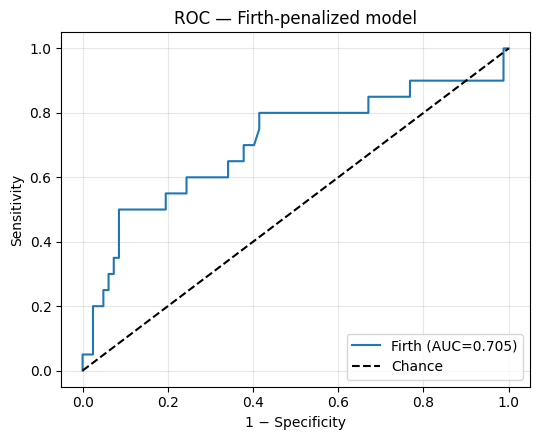

In [11]:
print('📋 Goodness of fit and discrimination\n')
eta = np.clip(X@bhat, -30, 30); prob = 1/(1+np.exp(-eta))

# Hosmer–Lemeshow
dfh = pd.DataFrame({'y':y,'p':prob}); dfh['g'] = pd.qcut(dfh.p, 10, duplicates='drop')
o = dfh.groupby('g', observed=True)['y'].agg(['sum','count']); e = dfh.groupby('g', observed=True)['p'].sum()
o['e']=e; o['eno']=o['count']-o['e']; o['ono']=o['count']-o['sum']
hl = (((o['sum']-o['e'])**2/o['e'])+((o['ono']-o['eno'])**2/o['eno'])).sum(); hldf=len(o)-2
print(f'   Hosmer–Lemeshow: χ² = {hl:.2f}, df = {hldf}, p = {1-stats.chi2.cdf(hl,hldf):.3f}')

# AUC + ROC
auc = roc_auc_score(y, prob)
print(f'   AUC = {auc:.3f}  ({"acceptable" if auc>=.7 else "poor"} discrimination)')
fpr, tpr, _ = roc_curve(y, prob)
plt.figure(figsize=(5.5,4.5))
plt.plot(fpr, tpr, label=f'Firth (AUC={auc:.3f})'); plt.plot([0,1],[0,1],'k--',label='Chance')
plt.xlabel('1 − Specificity'); plt.ylabel('Sensitivity'); plt.legend(loc='lower right')
plt.title('ROC — Firth-penalized model'); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig('roc_firth.png', dpi=300, bbox_inches='tight'); plt.show()

In [12]:
print('📋 Sensitivity analysis — excluding "Non sei" responses\n')
dfs = df[df.ai_clinical_use.isin(['Sí','Non'])]
Xs = sm.add_constant(dfs[preds]).values.astype(float); ys = dfs['ai_user'].values.astype(float)
bs = firth_fit(Xs, ys); lls = firth_loglik(bs, Xs, ys)
print(f'   n = {len(dfs)} (vs 102), events = {int(ys.sum())}, EPV = {int(ys.sum())/4:.1f}')
print('\n   Variable        OR      95% CI (profile)     p')
for j, v in enumerate(names):
    if v == 'const': continue
    lo, hi = profile_ci(Xs, ys, j, lls, bs[j]); _, p = plr_p(Xs, ys, j, lls)
    print(f'   {v:13s}{np.exp(bs[j]):7.3f}   ({np.exp(lo):.2f}–{np.exp(hi):.2f}){"":6}{p:.3f}')
print('\n   → Prior training remains the only significant predictor (direction unchanged).')

📋 Sensitivity analysis — excluding "Non sei" responses

   n = 80 (vs 102), events = 20, EPV = 5.0

   Variable        OR      95% CI (profile)     p
   has_training   2.996   (1.07–8.72)      0.037
   urban          0.375   (0.12–1.05)      0.063
   postgraduate   1.035   (0.34–3.05)      0.950
   age            1.007   (0.96–1.06)      0.751

   → Prior training remains the only significant predictor (direction unchanged).


## 9. Qualitative component: directed content analysis of open-ended responses (Table 4)

The two open-ended questions (perceived barriers; training interests) are analysed
with a **deductive (directed) content analysis** approach. A predefined dictionary
of terms (codebook) operationalises each category; each response is coded by
matching its text against the category terms. Coding is **lexical and rule-based**
(case-insensitive term matching), not interpretive thematic analysis, and does not
involve natural-language-processing models. Categories are **not mutually
exclusive** (a response may map to several), so prevalence is reported as the
percentage of respondents mentioning each category and percentages sum to >100%.

The full codebook is printed below so that the coding is fully reproducible.
Inter-coder reliability for this scheme is reported separately (Section 9.1).

In [ ]:
print('='*70); print('TABLE 4 — Directed content analysis (dictionary-based)'); print('='*70)

# ---------- Codebook (predefined dictionaries) ----------
barrier_codebook = {
    'Lack of Training / Knowledge': ['formación','formacion','training','knowledge',
        'coñecemento','conocimiento','desconocimiento','descoñecemento',
        'información','informacion','preparación','preparacion'],
    'Ethics and Privacy': ['ética','etico','ethics','privacy','privacidade',
        'confidencialidad','confidencialidade','datos','data','security',
        'seguridad','seguridade'],
    'Implementation / Technology': ['implementación','implementacion','integración',
        'integracion','tecnoloxía','tecnologia','software','desarrollo','desenvolvemento'],
    'Resources (Time / Infrastructure)': ['tempo','tiempo','recursos',
        'infraestructura','infrastructure'],
    'Economic Cost': ['económico','economico','económica','economica',
        'coste','custo','desembolso','presupuesto'],
    'Resistance to Change / Fear': ['medo','miedo','fear','reticencia',
        'reluctancia','humanización'],
}
training_codebook = {
    "Don't know": ['non sei','no sé','ni idea','ningunha','ninguna','desconozco','no se'],
    'Clinical Application / Care': ['clínica','clinica','coidados','cuidados',
        'tratamento','tratamiento','consulta','feridas','heridas','diagnóstico'],
    'General / Introduction': ['xeral','general','básico','basico','introducción','introduccion'],
    'Tool Usage': ['ferramenta','herramienta','tool','manejo','manexo'],
    'Research': ['investigación','investigacion','research','análise','análisis'],
    'Ethics and Legality': ['ética','etica','legal','lexislación','legislacion'],
}

def code_response(text, codebook):
    if pd.isna(text): return []
    t = str(text).lower().strip()
    if not t or t in ['.', ',', '-']: return []
    matched = [cat for cat, terms in codebook.items() if any(term in t for term in terms)]
    return matched if matched else ['Others / Non-specific']

df['barriers_codes'] = df['barriers_open'].apply(lambda x: code_response(x, barrier_codebook))
df['training_codes'] = df['training_areas_open'].apply(lambda x: code_response(x, training_codebook))

def prevalence(col, label):
    print(f'\n--- {label} (n responses = '
          f'{df[col].apply(lambda c: len(c)>0).sum()}) ---')
    flat = [c for sub in df[col] for c in sub]
    for cat, n in pd.Series(flat).value_counts().items():
        print(f'   {cat}: {n} ({n/len(df)*100:.1f}%)')

prevalence('barriers_codes', 'Barriers to AI integration')
prevalence('training_codes', 'Training interests')

# Print codebook for the supplementary material / reproducibility
print('\n📖 Codebook (barriers):')
for cat, terms in barrier_codebook.items():
    print(f'   {cat}: {", ".join(terms)}')

TABLE 4 — Directed content analysis (dictionary-based)

--- Barriers to AI integration (n responses = 101) ---
   Lack of Training / Knowledge: 80 (78.4%)
   Ethics and Privacy: 18 (17.6%)
   Implementation / Technology: 17 (16.7%)
   Economic Cost: 12 (11.8%)
   Resources (Time / Infrastructure): 12 (11.8%)
   Others / Non-specific: 11 (10.8%)
   Resistance to Change / Fear: 2 (2.0%)

--- Training interests (n responses = 99) ---
   Don't know: 41 (40.2%)
   Others / Non-specific: 36 (35.3%)
   Clinical Application / Care: 15 (14.7%)
   General / Introduction: 5 (4.9%)
   Tool Usage: 4 (3.9%)
   Research: 3 (2.9%)
   Ethics and Legality: 2 (2.0%)

📖 Codebook (barriers):
   Lack of Training / Knowledge: formación, formacion, training, knowledge, coñecemento, conocimiento, desconocimiento, descoñecemento, información, informacion, preparación, preparacion
   Ethics and Privacy: ética, etico, ethics, privacy, privacidade, confidencialidad, confidencialidade, datos, data, security, seguri

## 9.1 Inter-coder reliability

To assess the reliability of the directed content-analysis coding scheme, all 101
open-ended barrier responses were independently coded by two qualified coders
(authors with clinical and methodological expertise) using the predefined codebook.
Coders worked blind to each other. Agreement was quantified with Cohen's kappa per
category and as the mean across categories; disagreements were subsequently
resolved by consensus to produce the final coding used in Table 4.

This reliability assessment was conducted during manuscript revision and is
reported as such. Categories are not mutually exclusive, so kappa is computed per
category (presence/absence) and averaged.

In [14]:
from google.colab import files

categories = ['Lack of Training / Knowledge', 'Ethics and Privacy',
              'Implementation / Technology', 'Resources (Time / Infrastructure)',
              'Economic Cost', 'Resistance to Change / Fear', 'Others / Non-specific']

mask = df['barriers_open'].apply(
    lambda x: not (pd.isna(x) or str(x).strip() in ['', '.', ',', '-']))
template = pd.DataFrame({'id': df.index[mask],
                         'response_text': df.loc[mask, 'barriers_open'].values})
for c in categories:
    template[c] = ''   # each coder fills 1 (present) / 0 (absent)

template.to_excel('coding_template.xlsx', index=False)
print(f'✅ Template: {template.shape[0]} responses × {len(categories)} categories')
print('   Rule: mark "Others / Non-specific" = 1 only if no substantive category applies.')
print('   Duplicate for each coder → Revisor_1, Revisor_2')
files.download('coding_template.xlsx')

✅ Template: 101 responses × 7 categories
   Rule: mark "Others / Non-specific" = 1 only if no substantive category applies.
   Duplicate for each coder → Revisor_1, Revisor_2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from google.colab import files
from sklearn.metrics import cohen_kappa_score

categories = ['Lack of Training / Knowledge','Ethics and Privacy','Implementation / Technology',
              'Resources (Time / Infrastructure)','Economic Cost','Resistance to Change / Fear',
              'Others / Non-specific']

def load_coder(path):
    """Load a coder file (xlsx or csv, utf-8 or latin-1) and coerce category cols to 0/1."""
    if path.lower().endswith(('.xlsx', '.xls')):
        d = pd.read_excel(path)
    else:
        for enc in ['utf-8', 'latin-1']:
            try:
                d = pd.read_csv(path, encoding=enc); break
            except UnicodeDecodeError:
                continue
    d = d.sort_values('id').reset_index(drop=True)
    for c in categories:
        d[c] = pd.to_numeric(d[c], errors='coerce').fillna(0).astype(int)
    return d

# --- Upload the two coder files (Revisor_1.* and Revisor_2.*) ---
print('Upload BOTH coder files (Revisor_1 and Revisor_2):')
uploaded = files.upload()
names = list(uploaded.keys())
f1 = [n for n in names if '1' in n][0]
f2 = [n for n in names if '2' in n][0]
print(f'\nCoder 1 → {f1}\nCoder 2 → {f2}\n')

c1 = load_coder(f1)
c2 = load_coder(f2)
assert (c1['id'] == c2['id']).all(), 'Coder ids do not match'
print(f'Two coders, n = {len(c1)} responses\n')

print("Inter-coder reliability (Cohen's kappa per category):")
print(f'{"Category":36s}{"kappa":>8s}{"% agree":>10s}')
kappas = []
for c in categories:
    k = cohen_kappa_score(c1[c], c2[c]) if (c1[c].nunique() > 1 or c2[c].nunique() > 1) else 1.0
    kappas.append(k)
    print(f'{c:36s}{k:8.3f}{(c1[c]==c2[c]).mean()*100:9.1f}%')
mean_k = np.mean(kappas)
print(f'{"MEAN kappa":36s}{mean_k:8.3f}')
print(f'\nOverall agreement: {np.mean([(c1[c]==c2[c]).mean() for c in categories])*100:.1f}%')
print('Interpretation (Landis & Koch): 0.61–0.80 = substantial agreement')

Upload BOTH coder files (Revisor_1 and Revisor_2):


Saving Revisor 2.csv to Revisor 2.csv
Saving Revisor 1.csv to Revisor 1.csv

Coder 1 → Revisor 1.csv
Coder 2 → Revisor 2.csv

Two coders, n = 101 responses

Inter-coder reliability (Cohen's kappa per category):
Category                               kappa   % agree
Lack of Training / Knowledge           0.896     97.0%
Ethics and Privacy                     0.655     85.1%
Implementation / Technology            0.582     82.2%
Resources (Time / Infrastructure)      0.435     84.2%
Economic Cost                          0.848     95.0%
Resistance to Change / Fear            0.677     91.1%
Others / Non-specific                  0.382     89.1%
MEAN kappa                             0.639

Overall agreement: 89.1%
Interpretation (Landis & Koch): 0.61–0.80 = substantial agreement


In [17]:
from google.colab import files

# c1, c2 ya están cargados de la celda anterior (9.1b)
rows = []
for _, a in c1.iterrows():
    b = c2[c2.id == a.id].iloc[0]
    for c in categories:
        if a[c] != b[c]:
            rows.append({'id': a.id, 'response_text': a.response_text,
                         'category': c, 'coder1': a[c], 'coder2': b[c], 'consensus': ''})
disc = pd.DataFrame(rows)
disc.to_excel('discrepancies_to_resolve.xlsx', index=False)
print(f'{len(disc)} disagreements to resolve.')
print('Fill the "consensus" column with 1/0 (final agreed code) and save as '
      '"consensus_resolved.xlsx", then run the next cell.')
files.download('discrepancies_to_resolve.xlsx')

77 disagreements to resolve.
Fill the "consensus" column with 1/0 (final agreed code) and save as "consensus_resolved.xlsx", then run the next cell.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>